1. imports 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Model comparison notebook started.")


Model comparison notebook started.


3. Final Model Results

In [2]:
model_results = {
    "Custom CNN": {
        "best_validation_accuracy": 80.69,
        "test_accuracy": 80.30,
        "macro_f1": 80.56,
        "weighted_f1": 80.43,
        "total_parameters": 13235270,
        "trainable_parameters": 13235270
    },
    "ResNet18": {
        "best_validation_accuracy": 90.92,
        "test_accuracy": 91.00,
        "macro_f1": 91.16,
        "weighted_f1": 90.97,
        "total_parameters": 11179590,
        "trainable_parameters": 3078
    },
    "Vision Transformer (ViT)": {
        "best_validation_accuracy": 92.55,
        "test_accuracy": 92.17,
        "macro_f1": 92.35,
        "weighted_f1": 92.12,
        "total_parameters": 85803270,
        "trainable_parameters": 4614
    }
}

print("Final model results loaded successfully.")


Final model results loaded successfully.


4. Final Comparison Table


In [3]:
comparison = pd.DataFrame.from_dict(model_results, orient="index")
comparison.index.name = "Model"
comparison


,best_validation_accuracy,test_accuracy,macro_f1,weighted_f1,total_parameters,trainable_parameters
Model,,,,,,
Custom CNN,80.69,80.30,80.56,80.43,13235270,13235270
ResNet18,90.92,91.00,91.16,90.97,11179590,3078
Vision Transformer (ViT),92.55,92.17,92.35,92.12,85803270,4614


5. Test Accuracy Comparison

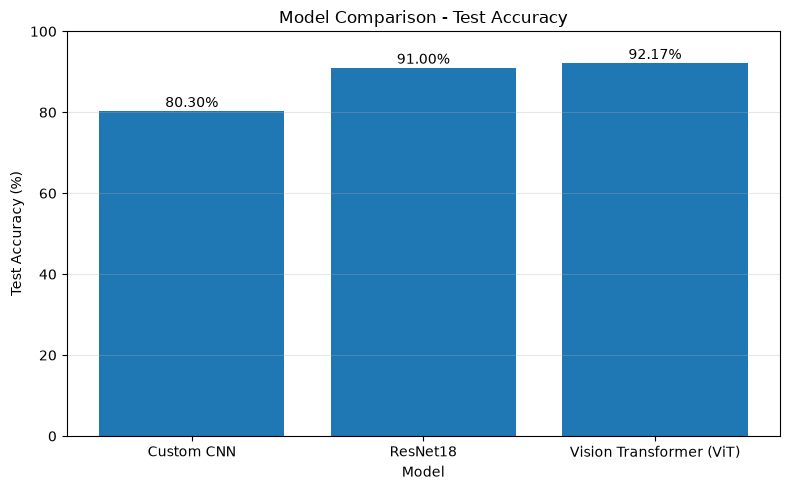

In [5]:
models = comparison.index
test_accuracies = comparison["test_accuracy"]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, test_accuracies)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Model Comparison - Test Accuracy")
plt.ylim(0, 100)

for bar, accuracy in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    r"D:\deep learning project\results\plots\final_model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

6. Validation vs Test Accuracy

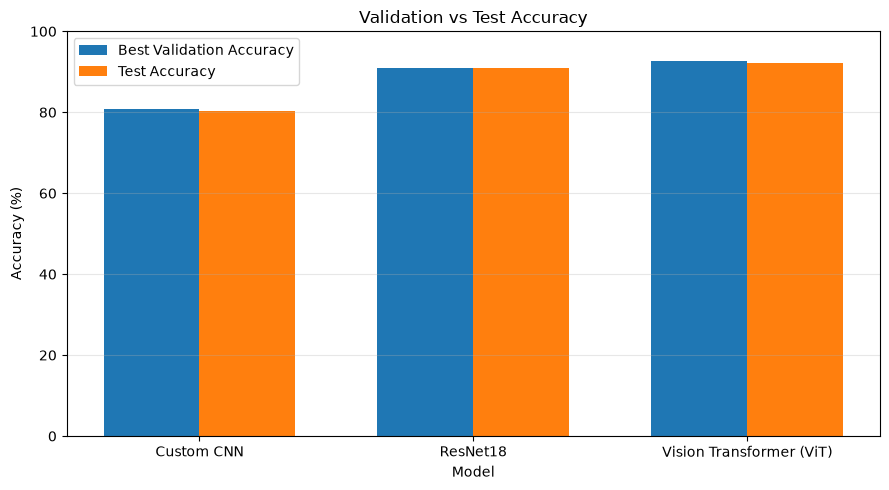

In [6]:
x = np.arange(len(comparison.index))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    comparison["best_validation_accuracy"],
    width,
    label="Best Validation Accuracy"
)

plt.bar(
    x + width / 2,
    comparison["test_accuracy"],
    width,
    label="Test Accuracy"
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Validation vs Test Accuracy")
plt.xticks(x, comparison.index)
plt.ylim(0, 100)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    r"D:\deep learning project\results\plots\validation_vs_test_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

7. Improvement Between Models

In [7]:
cnn_accuracy = comparison.loc["Custom CNN", "test_accuracy"]
resnet_accuracy = comparison.loc["ResNet18", "test_accuracy"]
vit_accuracy = comparison.loc["Vision Transformer (ViT)", "test_accuracy"]

print(f"Custom CNN: {cnn_accuracy:.2f}%")
print(f"ResNet18: {resnet_accuracy:.2f}%")
print(f"Vision Transformer: {vit_accuracy:.2f}%")

print()

print(
    f"ResNet18 improvement over Custom CNN: "
    f"{resnet_accuracy - cnn_accuracy:.2f} percentage points"
)

print(
    f"ViT improvement over Custom CNN: "
    f"{vit_accuracy - cnn_accuracy:.2f} percentage points"
)

print(
    f"ViT improvement over ResNet18: "
    f"{vit_accuracy - resnet_accuracy:.2f} percentage points"
)


Custom CNN: 80.30%
ResNet18: 91.00%
Vision Transformer: 92.17%

ResNet18 improvement over Custom CNN: 10.70 percentage points
ViT improvement over Custom CNN: 11.87 percentage points
ViT improvement over ResNet18: 1.17 percentage points


8. F1-Score Summary

In [8]:
f1_summary = comparison[
    ["macro_f1", "weighted_f1"]
].copy()

f1_summary


,macro_f1,weighted_f1
Model,,
Custom CNN,80.56,80.43
ResNet18,91.16,90.97
Vision Transformer (ViT),92.35,92.12


9. Parameter Summary

In [9]:
parameter_summary = comparison[
    ["total_parameters", "trainable_parameters"]
].copy()

parameter_summary


,total_parameters,trainable_parameters
Model,,
Custom CNN,13235270,13235270
ResNet18,11179590,3078
Vision Transformer (ViT),85803270,4614
